In [18]:
import pandas as pd

In [19]:
matches=pd.read_csv("matches.csv")
deliveries=pd.read_csv("deliveries.csv")

In [20]:
matches.head()
deliveries.head()


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [21]:
matches.shape
deliveries.shape

(179078, 21)

In [22]:
matches.isnull().sum()
deliveries.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batsman,0
non_striker,0
bowler,0
is_super_over,0


In [23]:
matches['winner'].value_counts()

,count
winner,
Mumbai Indians,109
Chennai Super Kings,100
Kolkata Knight Riders,92
Royal Challengers Bangalore,84
Kings XI Punjab,82
Rajasthan Royals,75
Delhi Daredevils,67
Sunrisers Hyderabad,58
Deccan Chargers,29


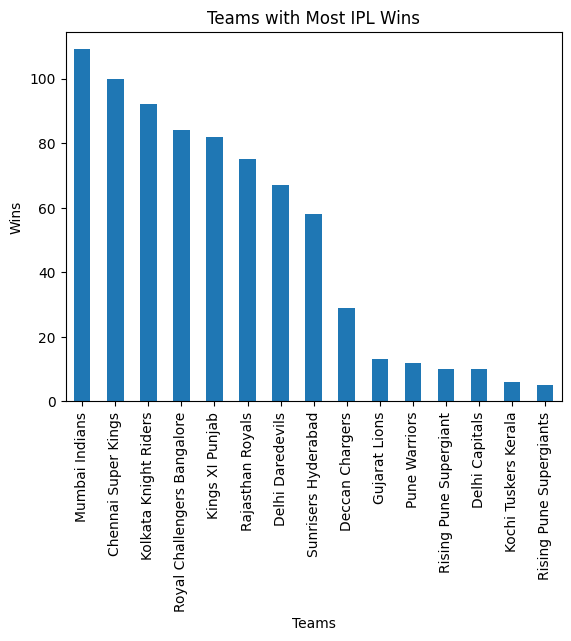

In [24]:
import matplotlib.pyplot as plt
matches['winner'].value_counts().plot(kind='bar')

plt.title("Teams with Most IPL Wins")
plt.xlabel("Teams")
plt.ylabel("Wins")

plt.show()


In [25]:
deliveries.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [26]:
deliveries.groupby('batsman')['batsman_runs'].sum()

,batsman_runs
batsman,
A Ashish Reddy,280
A Chandila,4
A Chopra,53
A Choudhary,25
A Dananjaya,4
...,...
YV Takawale,192
Yashpal Singh,47
Younis Khan,3


In [27]:
top_runs = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False)

top_runs.head(10)

,batsman_runs
batsman,
V Kohli,5434
SK Raina,5415
RG Sharma,4914
DA Warner,4741
S Dhawan,4632
CH Gayle,4560
MS Dhoni,4477
RV Uthappa,4446
AB de Villiers,4428


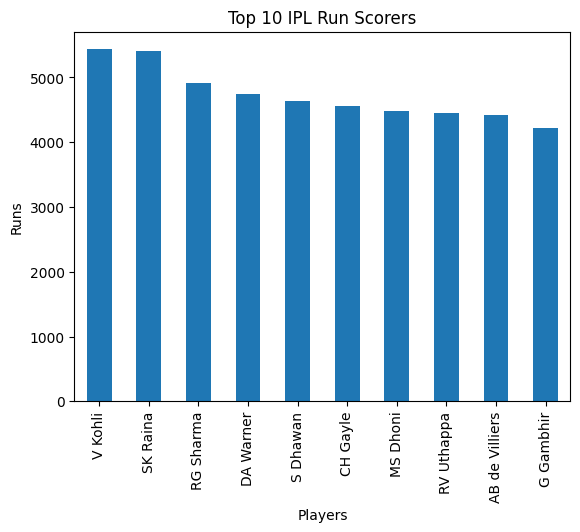

In [28]:
top_runs.head(10).plot(kind='bar')

plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Players")
plt.ylabel("Runs")

plt.show()

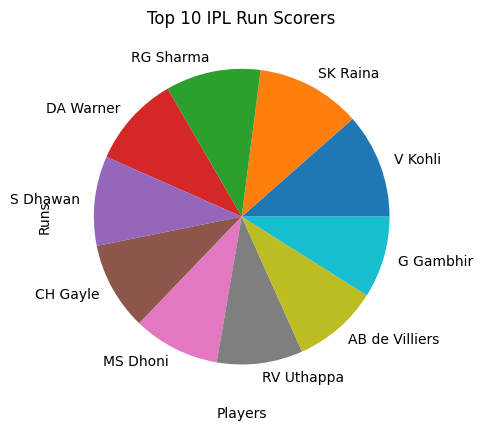

In [29]:
top_runs.head(10).plot(kind='pie')

plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Players")
plt.ylabel("Runs")

plt.show()

In [30]:
import pandas as pd

matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

In [31]:
deliveries.columns


Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [32]:
top_wickets = deliveries[deliveries['player_dismissed'].notnull()] \
.groupby('bowler')['player_dismissed'] \
.count() \
.sort_values(ascending=False)

top_wickets.head(10)

,player_dismissed
bowler,
SL Malinga,188
DJ Bravo,168
A Mishra,165
Harbhajan Singh,161
PP Chawla,156
B Kumar,141
R Ashwin,138
SP Narine,137
UT Yadav,136


In [33]:
import matplotlib.pyplot as plt


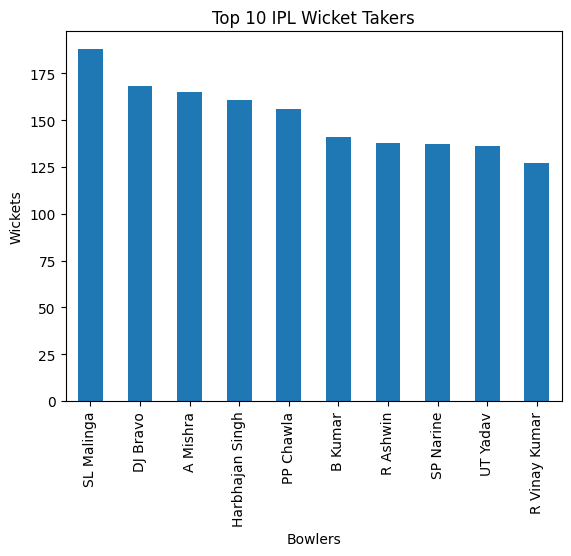

In [34]:
top_wickets.head(10).plot(kind='bar')

plt.title("Top 10 IPL Wicket Takers")
plt.xlabel("Bowlers")
plt.ylabel("Wickets")

plt.show()

In [35]:
powerplay_runs = deliveries[deliveries['over'] <= 6]['total_runs'].sum()

print("Total Powerplay Runs:", powerplay_runs)

Total Powerplay Runs: 69831


In [36]:
death_runs = deliveries[deliveries['over'] >= 16]['total_runs'].sum()

print("Total Death Over Runs:", death_runs)

Total Death Over Runs: 63478


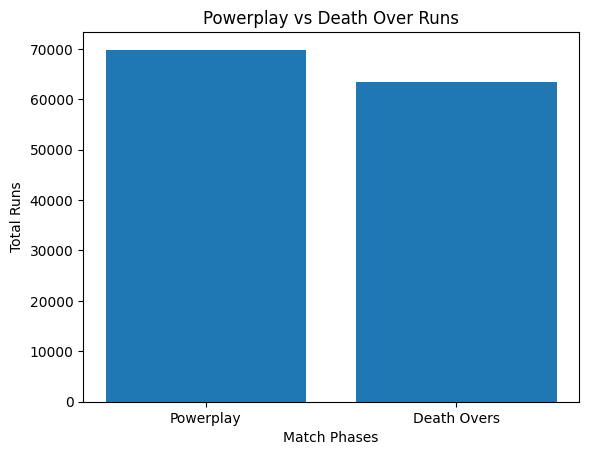

In [37]:
phases = ['Powerplay', 'Death Overs']
runs = [powerplay_runs, death_runs]

plt.bar(phases, runs)

plt.title("Powerplay vs Death Over Runs")
plt.xlabel("Match Phases")
plt.ylabel("Total Runs")

plt.show()

In [38]:
toss_match_win = matches[matches['toss_winner'] == matches['winner']]

percentage = (len(toss_match_win) / len(matches)) * 100

print("Toss winner also won the match:", percentage, "%")

Toss winner also won the match: 51.98412698412699 %


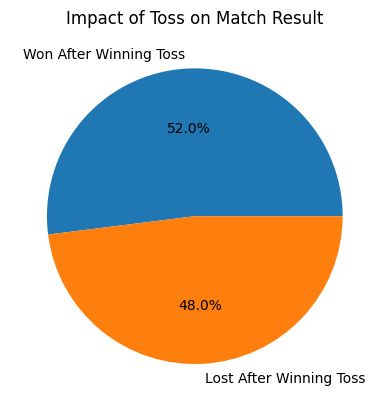

In [39]:
labels = ['Won After Winning Toss', 'Lost After Winning Toss']

won = len(toss_match_win)
lost = len(matches) - won

sizes = [won, lost]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.title("Impact of Toss on Match Result")

plt.show()